# 02 — Regime Detection

This notebook estimates latent market regimes from the feature panel created in `01_data_pipeline`.

The objective is not to discover a perfect market-state classifier. The objective is to construct an interpretable state variable that can be used for:

1. regime-conditioned risk diagnostics,
2. allocation stress control,
3. SMDP-inspired intervention policies.

Expected local outputs:

- `data/processed/regime_labels.csv`
- `data/processed/regime_probabilities.csv`
- `data/processed/hmm_transition_matrix.csv`
- `data/processed/regime_durations.csv`
- `reports/figures/02_stress_score_and_regimes.png`
- `reports/figures/02_regime_probabilities.png`
- `reports/figures/02_hmm_transition_matrix.png`

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"

DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.float_format", "{:,.4f}".format)

In [2]:
from regime_portfolio.features import stress_score
from regime_portfolio.regimes import (
    RegimeDetector,
    apply_minimum_regime_duration,
    regime_durations,
    smooth_regime_probabilities,
)

## 1. Load processed inputs

This notebook starts from the cleaned files exported by `01_data_pipeline`.

This is important for reproducibility: regime detection should not silently re-download or reshape data.

In [3]:
prices = pd.read_csv(DATA_DIR / "prices.csv", index_col=0, parse_dates=True)
returns = pd.read_csv(DATA_DIR / "returns.csv", index_col=0, parse_dates=True)
risk_features = pd.read_csv(DATA_DIR / "risk_features.csv", index_col=0, parse_dates=True)

print("Prices:", prices.shape)
print("Returns:", returns.shape)
print("Features:", risk_features.shape)

display(risk_features.tail())

Prices: (4851, 7)
Returns: (4850, 7)
Features: (4788, 5)


,SPY_realized_vol,SPY_drawdown,avg_corr,SPY_momentum,SPY_downside_semivol
Date,,,,,
2026-06-04,0.0965,-0.0033,0.0973,0.1143,0.0763
2026-06-05,0.1294,-0.0290,0.1136,0.0999,0.0872
2026-06-08,0.1290,-0.0268,0.1140,0.0928,0.0872
2026-06-09,0.1263,-0.0296,0.1145,0.0914,0.0872
2026-06-10,0.1373,-0.0449,0.1172,0.0755,0.0909


## 2. Construct a transparent stress score

Before fitting the HMM, we compute a deterministic stress score from the feature panel.

This score is not the final regime model. It is used for interpretation and for ordering the hidden states economically.

Higher stress should typically correspond to:

- higher volatility,
- deeper drawdowns,
- higher downside semivolatility,
- higher average correlation,
- weaker momentum.

In [4]:
score = stress_score(risk_features)

display(score.describe())

count   4,788.0000
mean       -0.0000
std         0.4050
min        -1.2028
25%        -0.2332
50%        -0.0760
75%         0.1498
max         2.2335
Name: stress_score, dtype: float64

## 3. Fit a Gaussian HMM

Raw HMM labels are arbitrary: state `0` does not naturally mean "calm" or "crisis".

The project therefore uses the `RegimeDetector` class from `src/regime_portfolio/regimes.py`, which:

1. standardizes the feature panel,
2. fits a Gaussian HMM,
3. predicts raw states,
4. reorders states by an economic stress proxy.

The ordered labels follow the convention:

```text
0 = lowest stress
1 = intermediate stress
2 = highest stress

In [5]:
detector = RegimeDetector(
    n_regimes=3,
    covariance_type="full",
    n_iter=1_000,
    random_state=42,
)

detector.fit(risk_features, risk_proxy=score)

regimes_raw_ordered = detector.predict(risk_features)
regime_probabilities = detector.predict_proba(risk_features)
regime_probabilities_smoothed = smooth_regime_probabilities(regime_probabilities, window=5)

hmm_transition_matrix = detector.transition_matrix()

display(hmm_transition_matrix)

,regime_0,regime_1,regime_2
regime_0,0.0013,0.9987,0.0000
regime_1,0.9808,0.0076,0.0115
regime_2,0.0023,0.0087,0.9890


## 4. Apply a minimum-duration filter

Very short regime flips are difficult to interpret economically and can create unstable allocation decisions.

We therefore apply a simple minimum-duration filter. This is not meant to hide genuine transitions; it is a readability and robustness device for the first public version.

In [6]:
regimes = apply_minimum_regime_duration(
    regimes_raw_ordered,
    min_duration=5,
).rename("regime")

durations = regime_durations(regimes)

display(regimes.value_counts().sort_index().rename("n_obs"))
display(durations.groupby("regime")["duration"].describe())

regime
1      45
2    4743
Name: n_obs, dtype: int64

,count,mean,std,min,25%,50%,75%,max
regime,,,,,,,,
1,1.0000,45.0000,NaN,45.0000,45.0000,45.0000,45.0000,45.0000
2,1.0000,"4,743.0000",NaN,"4,743.0000","4,743.0000","4,743.0000","4,743.0000","4,743.0000"


## 5. Visual diagnostic — stress score and regimes

This figure overlays the deterministic stress score with the ordered HMM regime label.

The main question is interpretability:

> Do higher-regime periods correspond to visibly more fragile market conditions?

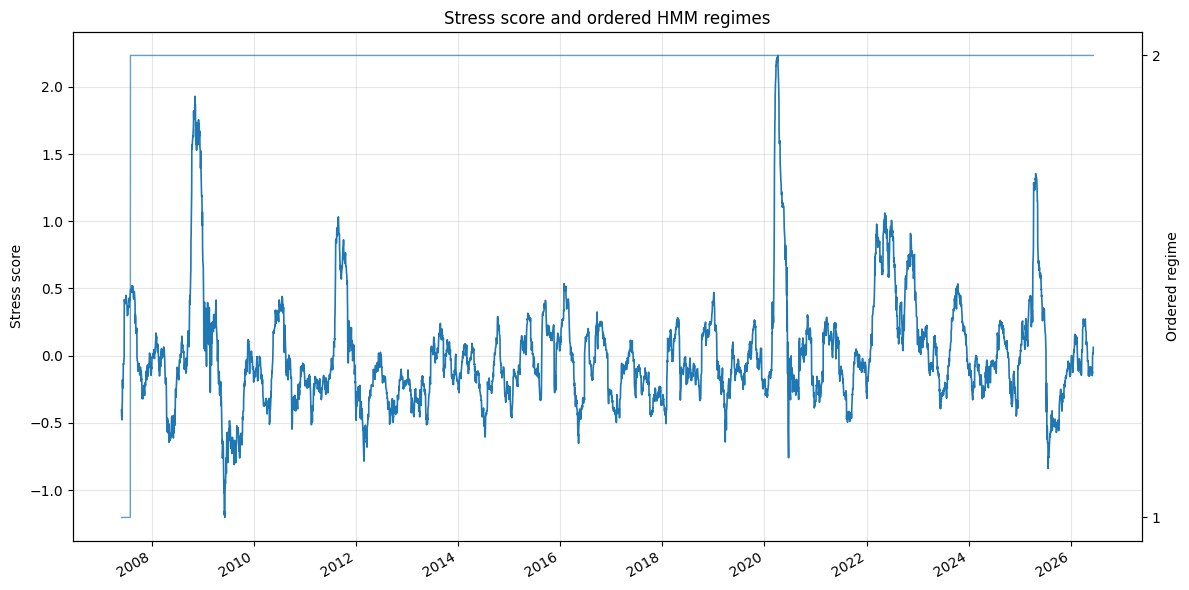

In [7]:
plot_df = pd.concat(
    [
        score.rename("stress_score"),
        regimes.rename("regime"),
    ],
    axis=1,
).dropna()

fig, ax1 = plt.subplots(figsize=(12, 6))

plot_df["stress_score"].plot(ax=ax1, linewidth=1.2)
ax1.set_title("Stress score and ordered HMM regimes")
ax1.set_ylabel("Stress score")
ax1.set_xlabel("")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
plot_df["regime"].plot(ax=ax2, linewidth=1.0, alpha=0.7)
ax2.set_ylabel("Ordered regime")
ax2.set_yticks(sorted(plot_df["regime"].unique()))

fig.tight_layout()
fig.savefig(FIGURE_DIR / "02_stress_score_and_regimes.png", dpi=150)
plt.show()

## 6. Visual diagnostic — smoothed regime probabilities

Regime probabilities are useful because they show uncertainty.

A hard label can make the model look more confident than it really is. The probability plot helps identify ambiguous transition periods.

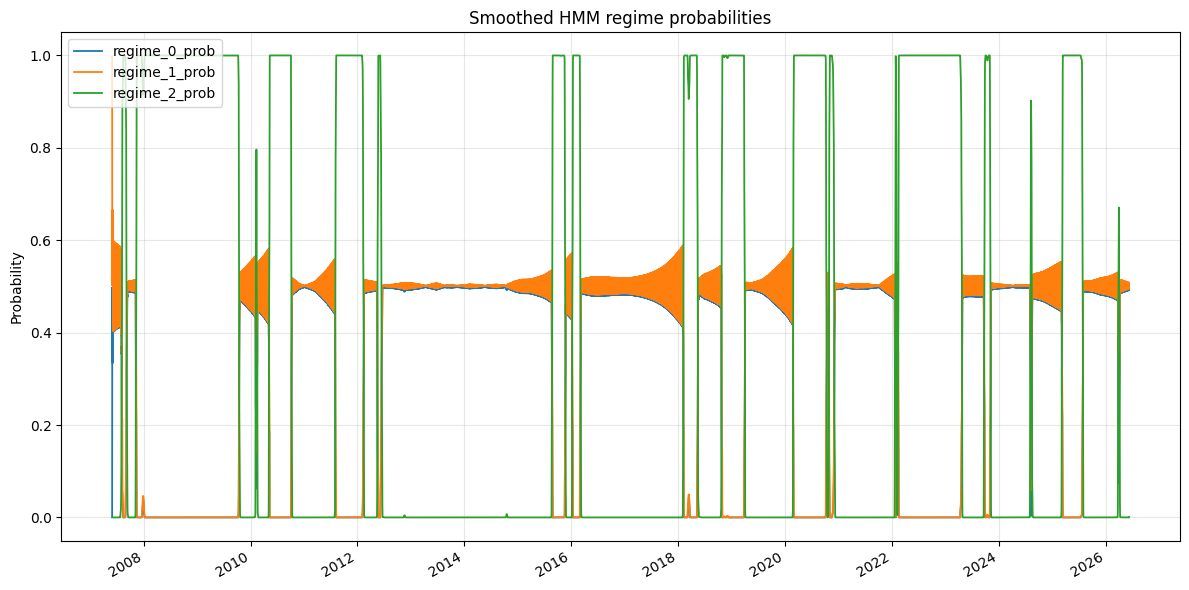

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

regime_probabilities_smoothed.plot(ax=ax, linewidth=1.3)

ax.set_title("Smoothed HMM regime probabilities")
ax.set_ylabel("Probability")
ax.set_xlabel("")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", ncols=1)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "02_regime_probabilities.png", dpi=150)
plt.show()

## 7. Visual diagnostic — transition matrix

The transition matrix summarizes estimated regime persistence.

High diagonal probabilities indicate persistent regimes. Large probabilities from low stress directly to high stress, or from high stress directly to low stress, would require interpretation and robustness checks.

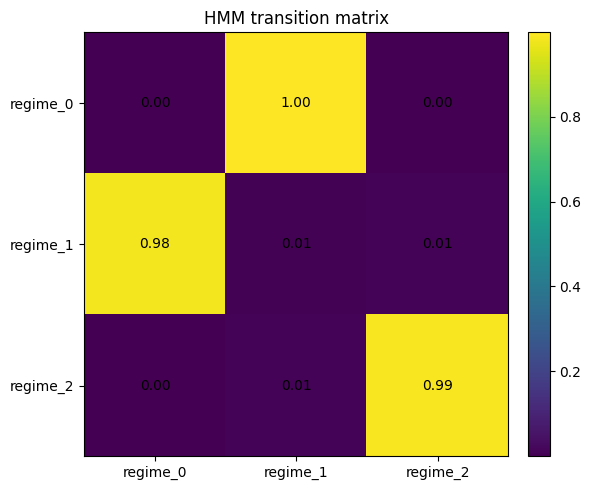

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(hmm_transition_matrix.values)
ax.set_title("HMM transition matrix")
ax.set_xticks(range(hmm_transition_matrix.shape[1]))
ax.set_yticks(range(hmm_transition_matrix.shape[0]))
ax.set_xticklabels(hmm_transition_matrix.columns)
ax.set_yticklabels(hmm_transition_matrix.index)

for i in range(hmm_transition_matrix.shape[0]):
    for j in range(hmm_transition_matrix.shape[1]):
        ax.text(
            j,
            i,
            f"{hmm_transition_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
        )

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "02_hmm_transition_matrix.png", dpi=150)
plt.show()

## 8. Export regime outputs

These files are the interface to downstream notebooks:

```text
02_regime_detection
  -> regime_labels.csv
  -> regime_probabilities.csv
  -> hmm_transition_matrix.csv
  -> regime_durations.csv

In [10]:
regimes.to_frame().to_csv(DATA_DIR / "regime_labels.csv")
regime_probabilities_smoothed.to_csv(DATA_DIR / "regime_probabilities.csv")
hmm_transition_matrix.to_csv(DATA_DIR / "hmm_transition_matrix.csv")
durations.to_csv(DATA_DIR / "regime_durations.csv", index=False)

print("Saved:")
print(DATA_DIR / "regime_labels.csv")
print(DATA_DIR / "regime_probabilities.csv")
print(DATA_DIR / "hmm_transition_matrix.csv")
print(DATA_DIR / "regime_durations.csv")

Saved:
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/regime_labels.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/regime_probabilities.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/hmm_transition_matrix.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/regime_durations.csv


## 9. Notebook takeaway

This notebook estimates ordered market regimes from interpretable risk features.

The output should be judged on economic plausibility and downstream usefulness, not on an exaggerated claim that the HMM "predicts crises".

The next notebook checks whether these regimes correspond to materially different volatility, drawdown, CVaR, and correlation profiles.